In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.models import Model

In [2]:
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
X_train = X_train/255.0
X_test = X_test/255.0
print(f"Training feature size: {X_train.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training feature size: (60000, 28, 28)


In [3]:
# Convolution expect input size as 3D - height x width x color
# Fashion MNIST dataset is 2D, convert it to 3D 
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)
print(f"New Training feature size: {X_train.shape}")

New Training feature size: (60000, 28, 28, 1)


In [7]:
# Total size of samples
print(f"samples: {X_train[0].shape}")

samples: (28, 28, 1)


In [6]:
# Number of classes
K = len(set(y_train))
print(f"Number of classes: {K}")

Number of classes: 10


In [28]:
# Building the model using functional API
i = Input(shape=X_train[0].shape)
x = Conv2D(32, (3, 3), strides=2, activation='relu')(i)
x = Conv2D(64, (3, 3), strides=2, activation='relu')(x)
x = Conv2D(128, (3, 3), strides=2, activation="relu")(x)
x = Flatten()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
x = Dense(K, activation="softmax")(x)

model = Model(i, x)

In [29]:
model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

r = model.fit(X_train,y_train, validation_data=(X_test,y_test), epochs = 10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7875 - loss: 0.5747 - val_accuracy: 0.8424 - val_loss: 0.4171
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8508 - loss: 0.4017 - val_accuracy: 0.8595 - val_loss: 0.3683
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8697 - loss: 0.3519 - val_accuracy: 0.8750 - val_loss: 0.3400
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8801 - loss: 0.3223 - val_accuracy: 0.8816 - val_loss: 0.3177
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8897 - loss: 0.2952 - val_accuracy: 0.8863 - val_loss: 0.3069
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8968 - loss: 0.2756 - val_accuracy: 0.8868 - val_loss: 0.3105
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9016 - loss: 0.2604 - val_accuracy: 0.8908 - val_loss: 0.3013
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9079 - loss: 0.2463 -

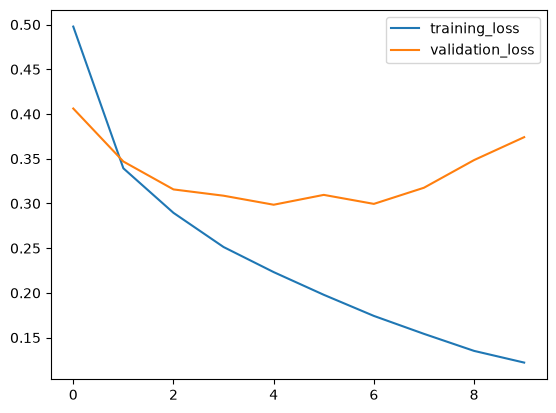

In [26]:
plt.plot(r.history['loss'],label='training_loss')
plt.plot(r.history['val_loss'], label='validation_loss')
plt.legend()

Model is overfitting as validation loss is higher than the training loss

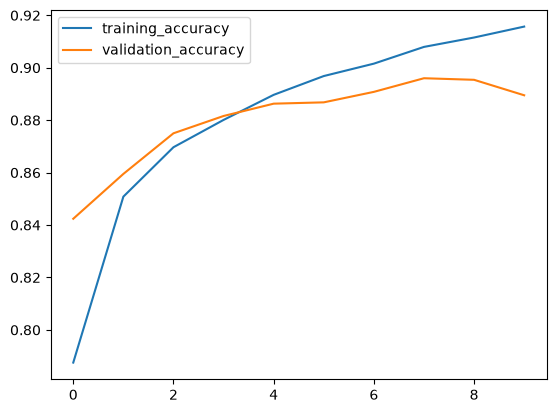

In [30]:
plt.plot(r.history['accuracy'], label='training_accuracy')
plt.plot(r.history['val_accuracy'], label='validation_accuracy')
plt.legend()

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
print(y_test)
print(y_pred)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[9 2 1 ... 8 1 5]
[9 2 1 ... 8 1 5]


In [32]:
# Labels
labels = '''T-shirts/top
Trouser
Pullover
Dress
Coat
Sandal
Shirt
Sneaker
Bag
Ankle boot'''.split()

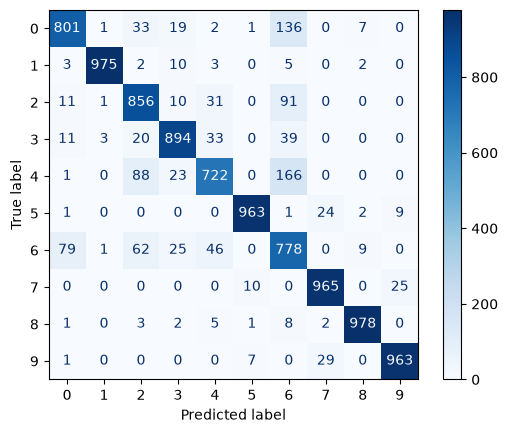

In [33]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues, values_format="d")

Text(0.5, 1.0, 'True Label: Pullover, Predicted Label: Shirt')

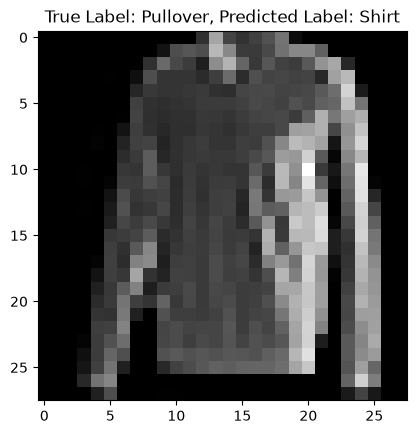

In [34]:
misclassified_idx = np.where(y_pred != y_test)[0]
i = np.random.choice(misclassified_idx)
plt.imshow(X_test[i], cmap='gray')
plt.title(f"True Label: {labels[y_test[i]]}, Predicted Label: {labels[y_pred[i]]}")